# Variational Autoencoder (VAE) — Summary

- **Dataset:** `MNIST` handwritten digits, normalized and reshaped to (28,28,1).
- **Reparameterization:** custom `Sampling` layer implements $z = u + \sigma \odot \epsilon$ so gradients can flow through stochastic sampling.
- **Architecture:** convolutional encoder produces `z_mean` and `z_log_var` (here `latent_dim=2`); decoder uses Dense + Conv2DTranspose to reconstruct images.
- **Loss:** custom `train_step` combines reconstruction loss (binary crossentropy) and KL divergence to regularize the latent distribution toward N(0,1).
- **Training & Visuals:** model is trained on `x_train` and the 2D latent space is visualized by decoding a grid of points to observe digit morphing.
- **Interactive Explorer:** the final cell adds `ipywidgets` sliders (`z1`, `z2`) that let you interactively set latent coordinates and display the decoded digit in real time (uses `vae.decoder.predict`).

This summary describes the code and intent of the cells that follow.

# 1. Setup and Data
We will use the MNIST digits dataset for this example, as the latent space distributions are very satisfying to visualize.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, losses, Model

# Load MNIST digits
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize and add channel dimension
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)


/opt/anaconda3/envs/tensorflow/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


# 2. The Reparameterization Trick
To allow backpropagation through a random sampling process, we use the Reparameterization Trick: $z = \mu + \sigma \odot \epsilon$, where $\epsilon$ is random noise.


In [2]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z (the vector encoding a digit)."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


# 3. VAE Architecture
The VAE loss consists of two parts: Reconstruction loss (how well the output matches the input) and KL Divergence (how close the latent distribution is to a standard normal distribution).


In [4]:

latent_dim = 2

# Encoder
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = Model(latent_inputs, decoder_outputs, name="decoder")

# Define VAE Model with custom train_step
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')
vae.fit(x_train, epochs=2, batch_size=128) # YOU CAN INCREASE EPOCHS FOR BETTER RESULTS

Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - kl_loss: 5.3307 - loss: 166.5907 - reconstruction_loss: 161.2600
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - kl_loss: 5.0200 - loss: 157.4891 - reconstruction_loss: 152.4691


# 4. Visualizing the Latent Space
Since we used latent_dim = 2, we can plot the latent space as a grid. By moving across the X and Y axes of the latent space, we can see one digit morph into another.Python


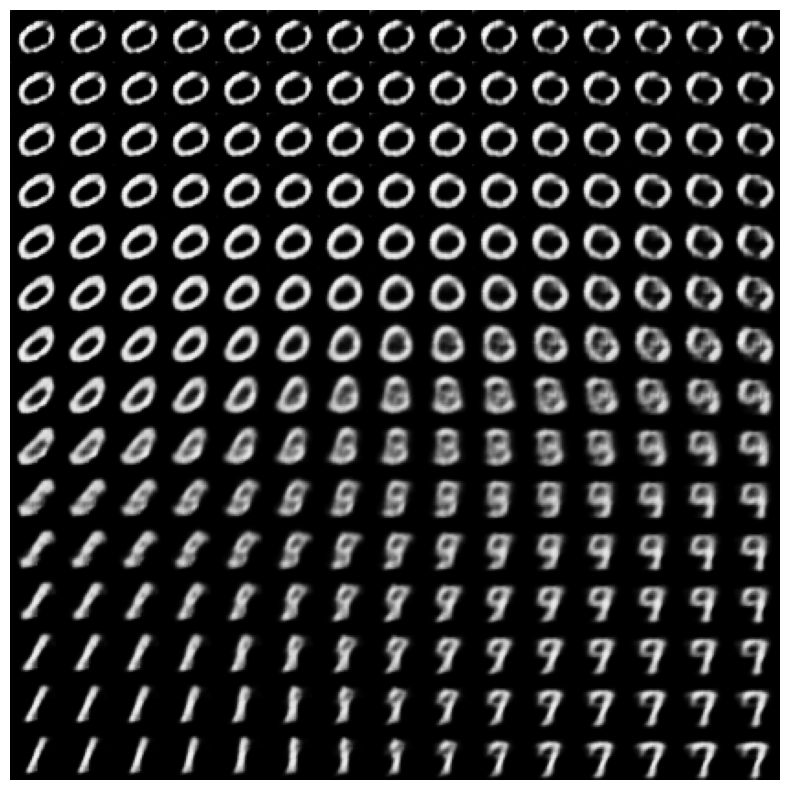

In [5]:

def plot_latent_space(vae, n=15, figsize=10):
    digit_size = 28
    scale = 2.0
    figure = np.zeros((digit_size * n, digit_size * n))

    # Linearly spaced coordinates corresponding to the 2D plot
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = vae.decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size,
                   j * digit_size : (j + 1) * digit_size] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.imshow(figure, cmap="Greys_r")
    plt.axis("off")
    plt.show()

plot_latent_space(vae)

In [ ]:
import ipywidgets as widgets
from IPython.display import display

def generate_digit(z1, z2):
    z_sample = np.array([[z1, z2]])
    x_decoded = vae.decoder.predict(z_sample, verbose=0)
    digit = x_decoded[0].reshape(28, 28)
    plt.figure(figsize=(3, 3))
    plt.imshow(digit, cmap='Greys_r')
    plt.axis('off')
    plt.title(f'z = [{z1:.2f}, {z2:.2f}]')
    plt.show()

z1_slider = widgets.FloatSlider(value=0, min=-3, max=3, step=0.1, description='z1:')
z2_slider = widgets.FloatSlider(value=0, min=-3, max=3, step=0.1, description='z2:')

widgets.interact(generate_digit, z1=z1_slider, z2=z2_slider)

interactive(children=(FloatSlider(value=0.0, description='z1:', max=3.0, min=-3.0), FloatSlider(value=0.0, des…

<function __main__.generate_digit(z1, z2)>